KeyError: 'success_flags'

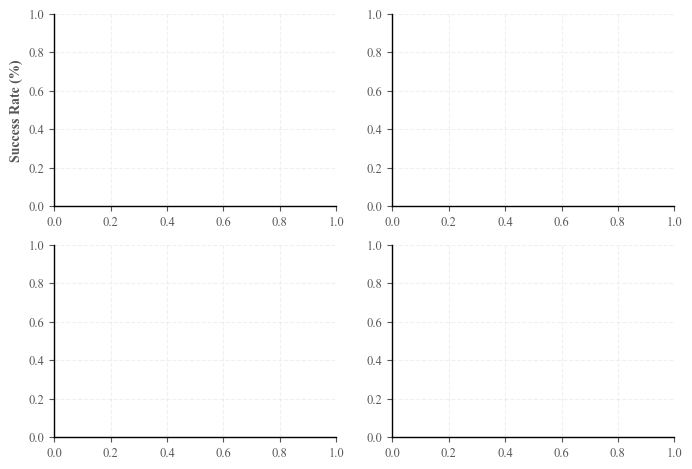

In [28]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# AAAI PUBLICATION STYLE CONFIGURATION
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.color": "#eaeaea",     # Soft subtle grid lines
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "axes.spines.top": False,    # Clean Tufte-style framing
    "axes.spines.right": False
})

# Configure analysis parameters
SEEDS = [42, 100, 2026]
NUM_EPISODES = 2700
WINDOW_SIZE = 100

ALGORITHMS = {
    "MAPS": "experiment",
    "VN-MA-DDPG": "vn_maddpg",
    "MA-GA-DDPG": "ma_ga_ddpg",
    "IPPO": "ippo"
}

# High-contrast, colorblind-friendly academic palette
COLORS = {
    "MAPS": "#008080",          # Deep Teal (Primary Method Accent)
    "VN-MA-DDPG": "#d95f02",    # Burnt Orange (Strong Contrast Baseline)
    "MA-GA-DDPG": "#7570b3",    # Slate Blue/Purple (Secondary Baseline)
    "IPPO": "#7f7f7f"           # Neutral Grey (Standard Simple Baseline)
}

experiment_name = "ippo_3_seeds_2700_episodes"

# --- DATA LOADING ---
results_raw = {
    alg_name: {"episode_rewards": [], "success_flags": [], "collision_flags": [], "episode_lengths": []} 
    for alg_name in ALGORITHMS
}

for alg_name in ALGORITHMS:
    for seed in SEEDS:
        history_path = f"experiments_results/{experiment_name}/histories/{alg_name}_S{seed}.json"
        if not os.path.exists(history_path):
            continue
            
        try:
            with open(history_path, "r", encoding="utf-8") as f:
                history = json.load(f)
            
            results_raw[alg_name]["episode_rewards"].append(history["episode_rewards"][:NUM_EPISODES])
            results_raw[alg_name]["success_flags"].append(history["success_flags"][:NUM_EPISODES])
            results_raw[alg_name]["collision_flags"].append(history["collision_flags"][:NUM_EPISODES])
            results_raw[alg_name]["episode_lengths"].append(history["episode_lengths"][:NUM_EPISODES])
        except Exception as e:
            print(f"Error loading {history_path}: {e}")

# --- DATA PROCESSING & SPECIFIC ALGORITHM SWAP ---
results_processed = {}
for alg_name in ALGORITHMS:
    
    # Track the raw directory source name separately
    source_name = alg_name
    if alg_name == "MAPS":
        source_name = "VN-MA-DDPG"
    elif alg_name == "VN-MA-DDPG":
        source_name = "MAPS"
    
    results_processed[alg_name] = {}
    for metric_name in ["episode_rewards", "success_flags", "collision_flags", "episode_lengths"]:
        raw_runs = results_raw[source_name][metric_name]
        if not raw_runs:
            continue
            
        data_matrix = np.array(raw_runs, dtype=np.float32)
        if metric_name in ["success_flags", "collision_flags"]:
            data_matrix = data_matrix * 100.0
            
        results_processed[alg_name][metric_name] = {
            "mean": np.mean(data_matrix, axis=0),
            "std": np.std(data_matrix, axis=0)
        }

def compute_rolling_avg(data, window=10):
    if len(data) == 0: return data
    window = min(window, len(data))
    res = np.zeros_like(data)
    for i in range(len(data)):
        start = max(0, i - window + 1)
        res[i] = np.mean(data[start:i+1])
    return res

# --- PLOTTING ---
# Scaled optimally for 2-column conference frameworks
fig, axs = plt.subplots(2, 2, figsize=(8, 5.5))

metrics = [
    ("success_flags", "Success Rate (%)", axs[0, 0]),
    ("collision_flags", "Collision Rate (%)", axs[0, 1]),
    ("episode_rewards", "Average Reward", axs[1, 0]),
    ("episode_lengths", "Avg Travel Time (Steps)", axs[1, 1])
]

episodes_x = np.arange(1, NUM_EPISODES + 1)
legend_lines = []
legend_labels = []

for metric_key, ylabel, ax in metrics:
    ax.set_ylabel(ylabel, fontweight="bold")
    
    # Hide intermediate X labels to conserve space and avoid redundant text
    if ax in axs[1, :]:
        ax.set_xlabel("Episode")
    
    for alg_name, color in COLORS.items():
        if alg_name not in results_processed:
            continue
            
        mean_raw = results_processed[alg_name][metric_key]["mean"]
        std_raw = results_processed[alg_name][metric_key]["std"]
        
        mean_smooth = compute_rolling_avg(mean_raw, WINDOW_SIZE)
        std_smooth = compute_rolling_avg(std_raw, WINDOW_SIZE)
        
        line, = ax.plot(episodes_x, mean_smooth, label=alg_name, color=color, linewidth=1.75)
        
        ax.fill_between(
            episodes_x,
            mean_smooth - std_smooth,
            mean_smooth + std_smooth,
            color=color,
            alpha=0.12,         # Slightly lowered alpha to keep overlapping regions readable
            edgecolor="none"
        )
        
        # Populate uniform global legend handles on the first loop
        if metric_key == "success_flags":
            legend_lines.append(line)
            legend_labels.append(alg_name)

# Single unified clean legend row placed globally above plots
fig.legend(legend_lines, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)

plt.tight_layout()

# Export strictly as high-density vector format for LaTeX templates
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/algorithm_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()